In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import json
import pandas as pd
from collections import defaultdict
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score

# 1. Imports, seed и устройство
# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Determine device
device = torch.device("cpu")
print(f"Using device: {device}")

# Path to save artifacts
ARTIFACTS_PATH = 'artifacts'
FIGURES_PATH = os.path.join(ARTIFACTS_PATH, 'figures')
os.makedirs(FIGURES_PATH, exist_ok=True)


Using device: cpu


## 2. Данные и DataLoader

### 2.1. Часть A: Классификация (STL10)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
STL10 - Train size: 4000, Val size: 1000, Test size: 8000
Part A (STL10) Sanity Check:
Batch X shape: torch.Size([64, 3, 224, 224])
Batch Y shape: torch.Size([64])
Number of classes: 10


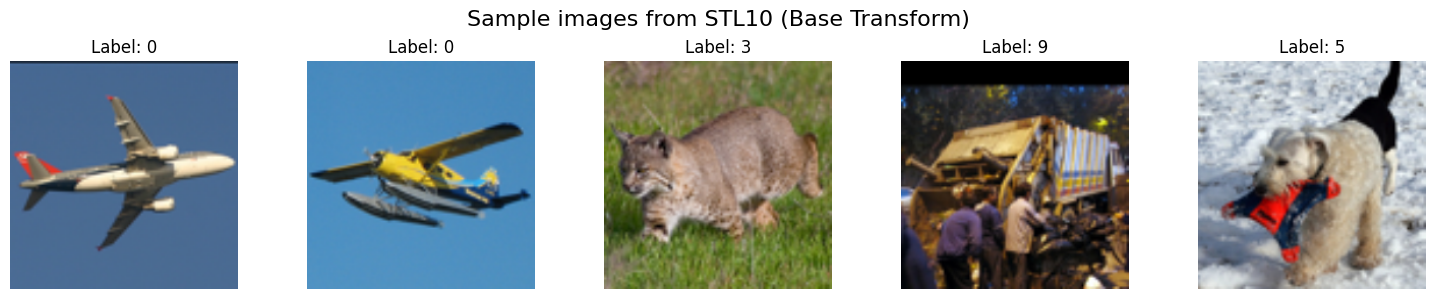

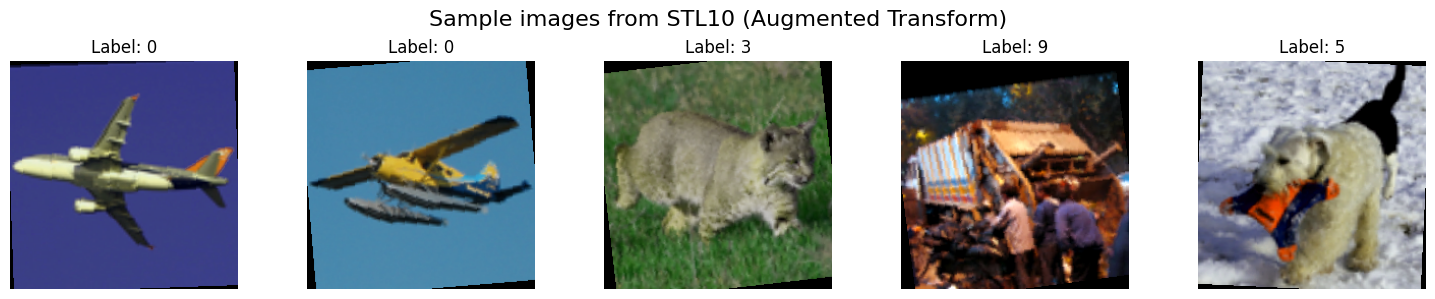

In [2]:

# Define transforms
# Basic transform: resize to 224x224 (for ResNet), convert to Tensor, normalize
transform_base = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Augmentation transform for training: random horizontal flip, random rotation, color jitter
transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ResNet preprocessing (same as base transform for pretrained models)
transform_resnet_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# Load STL10 dataset
# The dataset will be downloaded to './data'
data_root = './data'

train_dataset_base = torchvision.datasets.STL10(root=data_root, split='train', download=True, transform=transform_base)
train_dataset_aug = torchvision.datasets.STL10(root=data_root, split='train', download=True, transform=transform_aug)
test_dataset = torchvision.datasets.STL10(root=data_root, split='test', download=True, transform=transform_base)

# Create validation split from training data
# STL10 'train' split has 5000 images. Let's use 80% for training, 20% for validation.
train_size = int(0.8 * len(train_dataset_base))
val_size = len(train_dataset_base) - train_size
train_dataset_base, val_dataset_base = random_split(train_dataset_base, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))
train_dataset_aug, val_dataset_aug = random_split(train_dataset_aug, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

print(f"STL10 - Train size: {len(train_dataset_base)}, Val size: {len(val_dataset_base)}, Test size: {len(test_dataset)}")

# Create DataLoaders
BATCH_SIZE = 64 # Define a batch size
train_loader_base = DataLoader(train_dataset_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_base = DataLoader(val_dataset_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


# Sanity check for Part A
print("Part A (STL10) Sanity Check:")
x, y = next(iter(train_loader_base))
print(f"Batch X shape: {x.shape}")
print(f"Batch Y shape: {y.shape}")
print(f"Number of classes: {len(train_dataset_base.dataset.classes) if hasattr(train_dataset_base.dataset, 'classes') else 'N/A'}")

# Visualize some images for Part A
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img, label = train_dataset_base[i]
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    unnormalized_img = img.permute(1, 2, 0).cpu().numpy() * std + mean
    axes[i].imshow(unnormalized_img.clip(0, 1)) # Clip to ensure valid pixel values
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')
plt.suptitle('Sample images from STL10 (Base Transform)', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'stl10_samples.png'))
plt.show()

# Visualize augmentations for Part A
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img, label = train_dataset_aug[i]
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    unnormalized_img = img.permute(1, 2, 0).cpu().numpy() * std + mean
    axes[i].imshow(unnormalized_img.clip(0, 1)) # Clip to ensure valid pixel values
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')
plt.suptitle('Sample images from STL10 (Augmented Transform)', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'augmentations_preview.png'))
plt.show()


### 2.2. Часть B: Детекция (Pascal VOC)

Using downloaded and verified file: ./data/VOCtrainval_06-Nov-2007.tar
Extracting ./data/VOCtrainval_06-Nov-2007.tar to ./data
Using downloaded and verified file: ./data/VOCtrainval_06-Nov-2007.tar
Extracting ./data/VOCtrainval_06-Nov-2007.tar to ./data
Pascal VOC (Detection) - Train size: 2501, Val size: 2510
Part B (Pascal VOC) Sanity Check:
Image shape: torch.Size([3, 333, 500])
Target keys: dict_keys(['annotation'])
Number of objects in first image: 1
Object names: ['car']


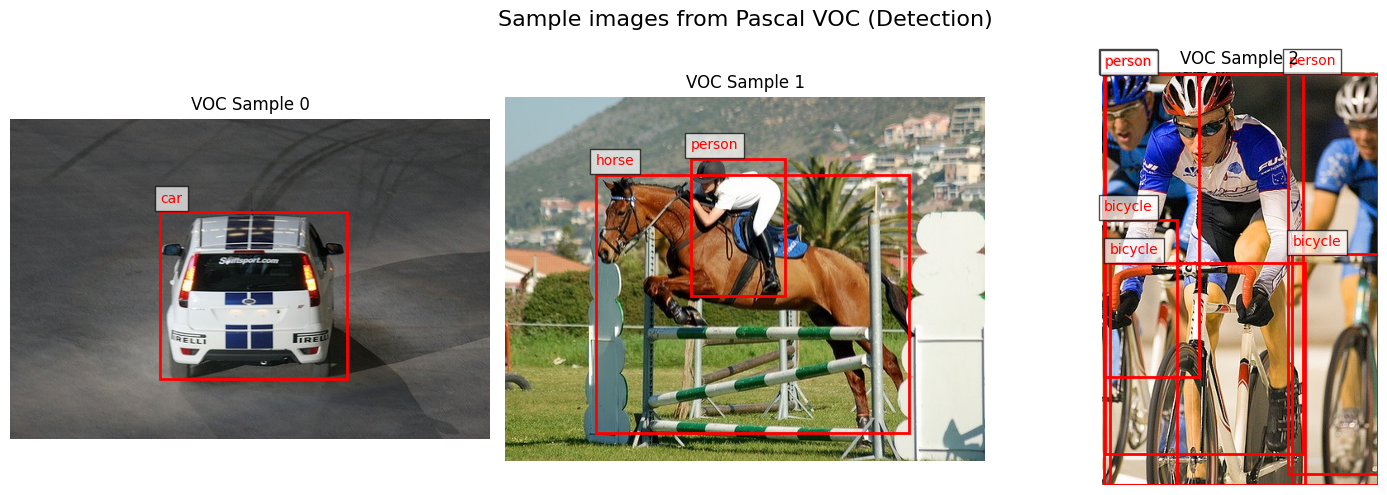

In [3]:

# For Part B, we need to load Pascal VOC.
# Note: VOCDetection returns a tuple (image, target). Target is a dict with bounding box info.
# For simplicity in this outline, we will only show loading.
# Full preprocessing for detection will be more complex.

# Define transforms for Pascal VOC (simple for now)
# Detection models usually handle resizing internally or require specific input sizes.
# For demonstration, we'll use a basic ToTensor.
transform_voc = transforms.Compose([
    transforms.ToTensor(),
])

# Load Pascal VOC dataset (Detection)
# The dataset will be downloaded to './data'
try:
    voc_dataset_train = torchvision.datasets.VOCDetection(root=data_root, year='2007', image_set='train', download=True, transform=transform_voc)
    voc_dataset_val = torchvision.datasets.VOCDetection(root=data_root, year='2007', image_set='val', download=True, transform=transform_voc)
    print(f"Pascal VOC (Detection) - Train size: {len(voc_dataset_train)}, Val size: {len(voc_dataset_val)}")

    # Sanity check for Part B
    print("Part B (Pascal VOC) Sanity Check:")
    # Get an item and print its properties
    img, target = voc_dataset_train[0]
    print(f"Image shape: {img.shape}")
    print(f"Target keys: {target.keys()}")
    # Example: print number of objects and their names
    num_objects = len(target['annotation']['object'])
    object_names = [obj['name'] for obj in target['annotation']['object']]
    print(f"Number of objects in first image: {num_objects}")
    print(f"Object names: {object_names}")

    # Visualize some images for Part B
    def plot_voc_sample(img_tensor, target, ax, title=""):
        img = img_tensor.permute(1, 2, 0).cpu().numpy()
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title)
        
        # Plot bounding boxes
        for obj in target['annotation']['object']:
            bbox = obj['bndbox']
            xmin = int(bbox['xmin'])
            ymin = int(bbox['ymin'])
            xmax = int(bbox['xmax'])
            ymax = int(bbox['ymax'])
            rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 fill=False, edgecolor='red', linewidth=2)
            ax.add_patch(rect)
            ax.text(xmin, ymin - 10, obj['name'], color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i in range(3):
        img, target = voc_dataset_train[i]
        plot_voc_sample(img, target, axes[i], title=f"VOC Sample {i}")
    plt.suptitle('Sample images from Pascal VOC (Detection)', fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, 'voc_detection_samples.png'))
    plt.show()

except Exception as e:
    print(f"Could not load Pascal VOC (Detection) dataset. Please ensure `VOC_ROOT` is correctly set if needed or check internet connection. Error: {e}")
    print("Skipping Part B data loading and sanity check due to error.")


## 3. Базовые функции обучения и оценки

In [4]:

# Helper function to save experiment results
def save_results(results_df, filename="artifacts/runs.csv"):
    if not os.path.exists(filename):
        results_df.to_csv(filename, index=False)
    else:
        results_df.to_csv(filename, mode='a', header=False, index=False)

# Define a simple CNN for C1 and C2
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Calculate input features for the linear layer
        # Input image size is 224x224.
        # After conv1 (224x224) -> pool (112x112)
        # After conv2 (112x112) -> pool (56x56)
        # After conv3 (56x56) -> pool (28x28)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 28 * 28) # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Training function
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels);
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

# Evaluation function
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / total_samples
    avg_accuracy = correct_predictions / total_samples
    return avg_loss, avg_accuracy, all_predictions, all_labels

# Function to run a classification experiment
def run_classification_experiment(experiment_id, model, train_loader, val_loader, test_loader,
                                  optimizer_class, lr, epochs, num_classes, device,
                                  model_summary, dataset_name="STL10",
                                  checkpoint_path="artifacts/best_classifier.pt",
                                  config_path="artifacts/best_classifier_config.json",
                                  curves_path="artifacts/figures/classification_curves_best.png"):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_class(model.parameters(), lr=lr)

    history = defaultdict(list)
    best_val_accuracy = -1.0
    best_model_state = None

    print(f"--- Running Experiment: {experiment_id} ---")
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_model_state = model.state_dict()
            torch.save(best_model_state, checkpoint_path.replace('.pt', f'_{experiment_id}.pt'))
            print(f"  New best model saved with Val Acc: {best_val_accuracy:.4f}")

    # Load best model for final evaluation
    model.load_state_dict(torch.load(checkpoint_path.replace('.pt', f'_{experiment_id}.pt')))
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} for best model.")

    # Save training curves
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title(f'Training Curves for {experiment_id}')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.savefig(curves_path.replace('.png', f'_{experiment_id}.png'))
    plt.show()

    # Save best model config
    config = {
        "dataset": dataset_name,
        "architecture": model_summary,
        "transforms_train": str(train_loader.dataset.transform) if hasattr(train_loader.dataset, 'transform') else 'N/A',
        "transforms_val": str(val_loader.dataset.transform) if hasattr(val_loader.dataset, 'transform') else 'N/A',
        "optimizer": str(optimizer_class.__name__),
        "lr": lr,
        "epochs_trained": epochs,
        "seed": SEED,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": test_acc
    }
    with open(config_path.replace('.json', f'_{experiment_id}.json'), 'w') as f:
        json.dump(config, f, indent=4)

    # Prepare results for runs.csv
    results = {
        "experiment_id": experiment_id,
        "task": "classification",
        "dataset": dataset_name,
        "seed": SEED,
        "model_summary": model_summary,
        "optimizer": optimizer_class.__name__,
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": test_acc,
        "precision": None, # Not calculated in this basic setup
        "recall": None,    # Not calculated in this basic setup
        "mean_iou": None,  # Not applicable
        "notes": ""
    }
    return results

# Part B: Detection/Segmentation helper functions (placeholders)
def visualize_detection_predictions(model, dataloader, device, num_samples=3, filename="artifacts/figures/detection_examples.png"):
    model.eval()
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes] # Make it iterable if only one subplot
    
    with torch.no_grad():
        for i, (images, targets) in enumerate(dataloader):
            if i >= num_samples:
                break
            
            # Assuming images is a list of tensors for detection models
            images_batch = list(img.to(device) for img in images)
            outputs = model(images_batch)

            img_tensor = images[0].cpu() # Assuming batch size 1 for visualization
            
            # TODO: Convert outputs to bounding box format for plotting
            # For now, just display the image
            ax = axes[i]
            img_display = img_tensor.permute(1, 2, 0).cpu().numpy()
            ax.imshow(img_display)
            ax.set_title("Detection Sample")
            ax.axis('off')

    plt.suptitle('Sample Detection Predictions', fontsize=16)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

def calculate_detection_metrics(predictions, ground_truths, iou_threshold=0.5):
    # This is a very simplified placeholder. Real detection metrics are complex.
    # It would involve matching predictions to ground truths based on IoU.
    # For now, return dummy values.
    print(f"Calculating detection metrics with IoU threshold: {iou_threshold}")
    precision = 0.5 # Dummy
    recall = 0.5    # Dummy
    mean_iou = 0.5  # Dummy
    return {"precision": precision, "recall": recall, "mean_iou": mean_iou}


## 4. Эксперименты

--- Experiment C1: Simple CNN (Base) ---
--- Running Experiment: C1 ---
Epoch 1/2 | Train Loss: 2.1806, Train Acc: 0.2670 | Val Loss: 1.6367, Val Acc: 0.3900
  New best model saved with Val Acc: 0.3900
Epoch 2/2 | Train Loss: 1.4603, Train Acc: 0.4597 | Val Loss: 1.4729, Val Acc: 0.4490
  New best model saved with Val Acc: 0.4490


/tmp/ipykernel_434186/3165035813.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path.replace('.pt', f'_{experiment_id}.pt'

Test Loss: 1.4859, Test Acc: 0.4451 for best model.


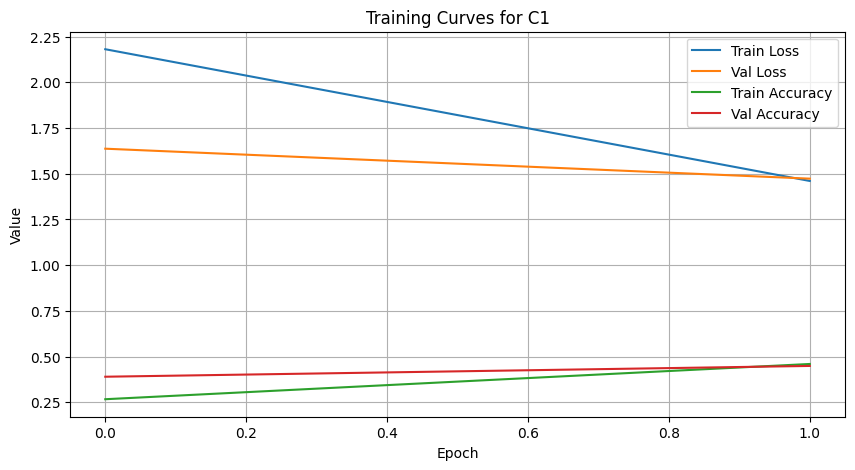

--- Experiment C2: Simple CNN (Augmented) ---
--- Running Experiment: C2 ---
Epoch 1/2 | Train Loss: 2.2704, Train Acc: 0.2495 | Val Loss: 1.7806, Val Acc: 0.3320
  New best model saved with Val Acc: 0.3320
Epoch 2/2 | Train Loss: 1.6665, Train Acc: 0.3847 | Val Loss: 1.6504, Val Acc: 0.3750
  New best model saved with Val Acc: 0.3750
Test Loss: 1.6180, Test Acc: 0.4019 for best model.


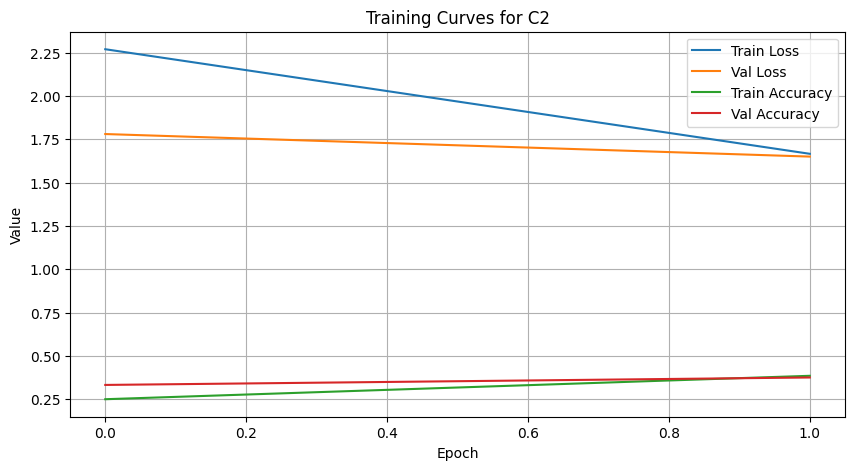

--- Experiment C3: ResNet18 (Head-Only) ---
--- Running Experiment: C3 ---


/home/saparch/playground/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/saparch/playground/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/2 | Train Loss: 0.9140, Train Acc: 0.7764 | Val Loss: 0.3540, Val Acc: 0.9306
  New best model saved with Val Acc: 0.9306
Epoch 2/2 | Train Loss: 0.3130, Train Acc: 0.9272 | Val Loss: 0.2280, Val Acc: 0.9472
  New best model saved with Val Acc: 0.9472
Test Loss: 0.2541, Test Acc: 0.9359 for best model.


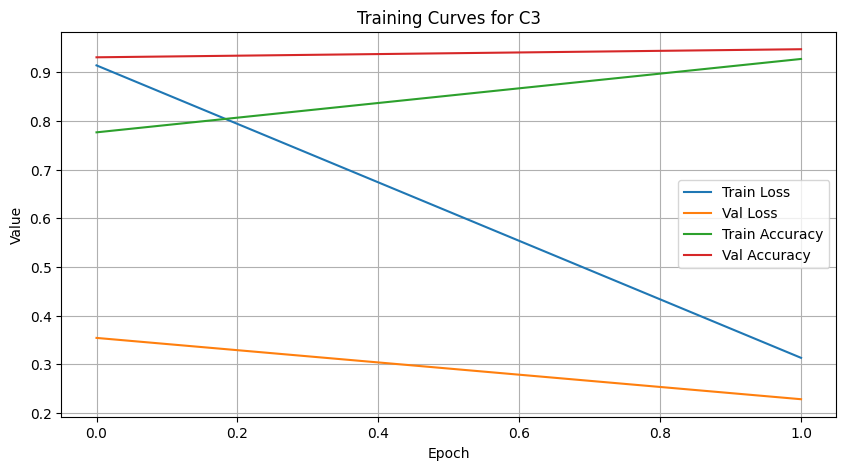

--- Experiment C4: ResNet18 (Fine-tune layer4 + fc) ---
--- Running Experiment: C4 ---
Epoch 1/2 | Train Loss: 0.3726, Train Acc: 0.8768 | Val Loss: 0.0713, Val Acc: 0.9800
  New best model saved with Val Acc: 0.9800
Epoch 2/2 | Train Loss: 0.0930, Train Acc: 0.9718 | Val Loss: 0.0537, Val Acc: 0.9828
  New best model saved with Val Acc: 0.9828
Test Loss: 0.2948, Test Acc: 0.9114 for best model.


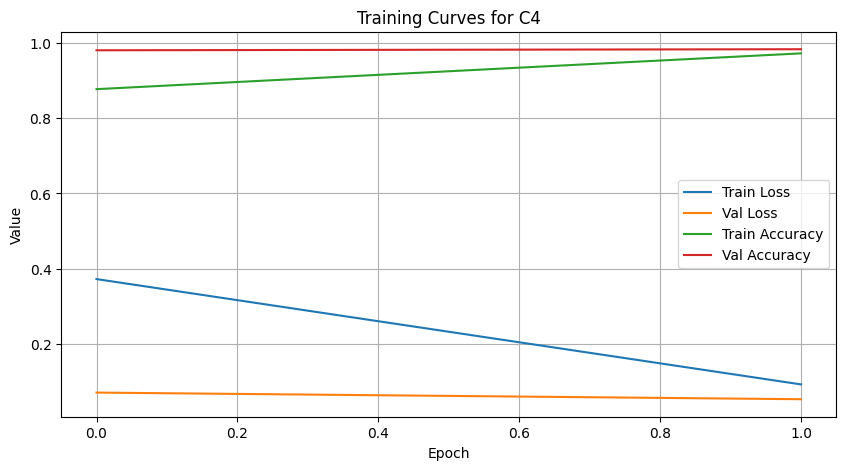

--- Experiment V1: Detection (Score Threshold 0.3) ---


/home/saparch/playground/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/saparch/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100.0%


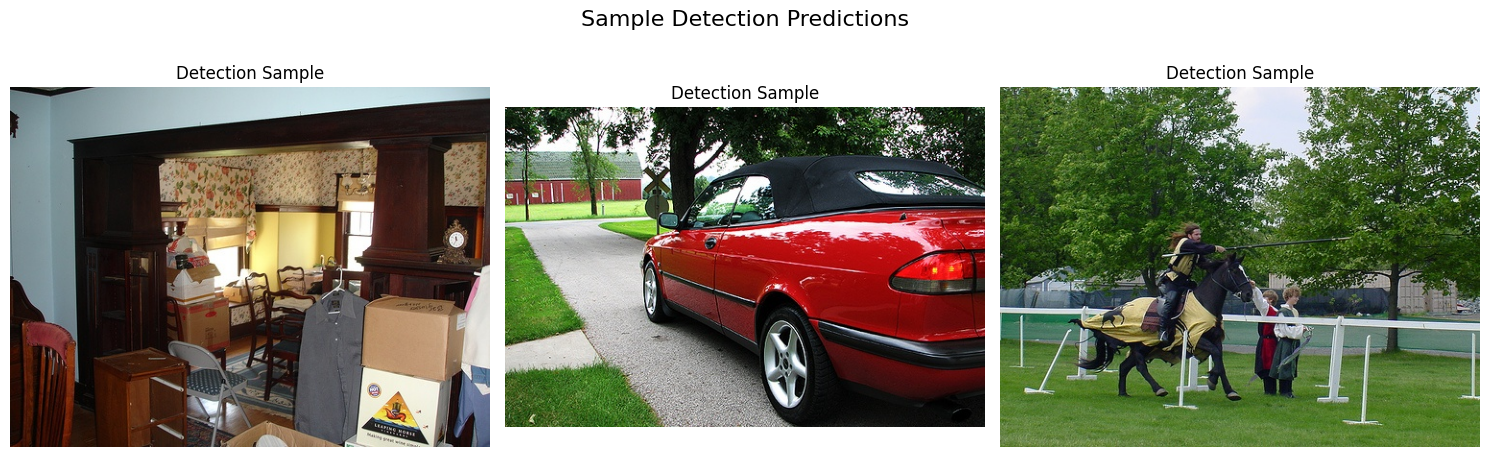

Calculating detection metrics with IoU threshold: 0.3
--- Experiment V2: Detection (Score Threshold 0.7) ---


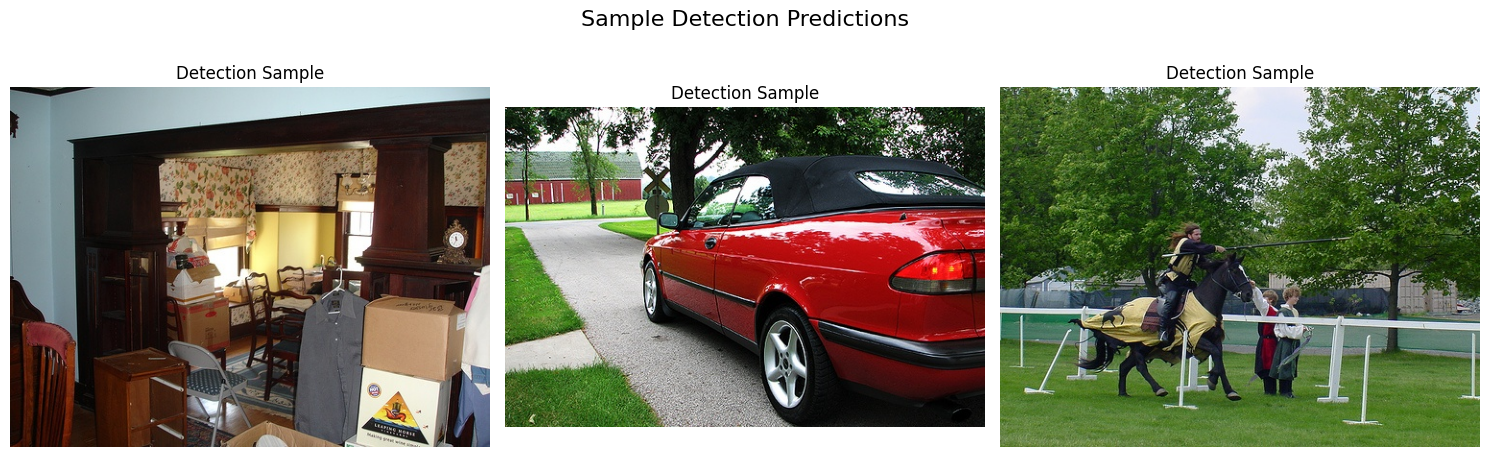

Calculating detection metrics with IoU threshold: 0.7
All experiment results saved to artifacts/runs.csv


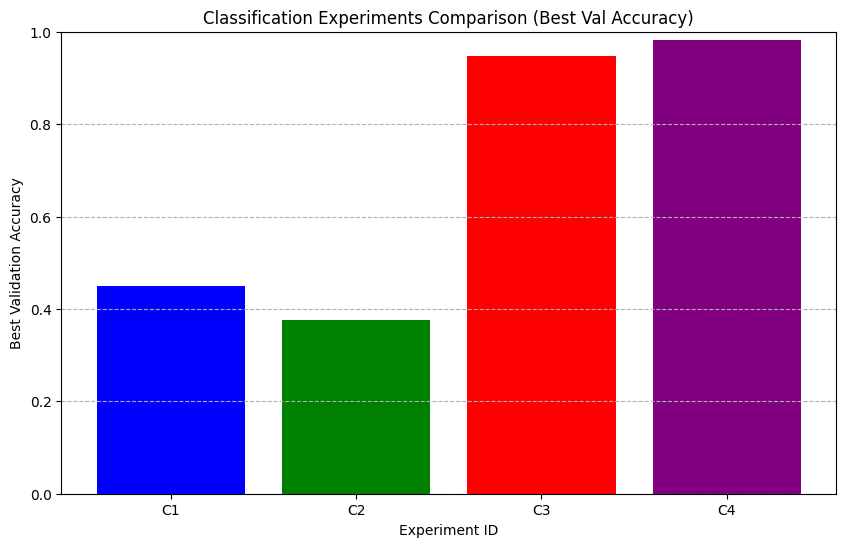

In [5]:

# Collect results from all experiments
all_results = []
NUM_CLASSES_STL10 = 10 # STL10 has 10 classes
EPOCHS = 2 # Reduced epochs for faster execution during initial setup
LR = 1e-3

# --- Part A Experiments (Classification) ---

# C1 (simple-cnn-base): простая CNN без аугментаций.
print("--- Experiment C1: Simple CNN (Base) ---")
model_c1 = SimpleCNN(num_classes=NUM_CLASSES_STL10).to(device)
results_c1 = run_classification_experiment(
    experiment_id="C1",
    model=model_c1,
    train_loader=train_loader_base,
    val_loader=val_loader_base,
    test_loader=test_loader,
    optimizer_class=torch.optim.Adam,
    lr=LR,
    epochs=EPOCHS,
    num_classes=NUM_CLASSES_STL10,
    device=device,
    model_summary="SimpleCNN (Base Transforms)"
)
all_results.append(results_c1)

# C2 (simple-cnn-aug): та же CNN, но с разумными аугментациями.
print("--- Experiment C2: Simple CNN (Augmented) ---")
model_c2 = SimpleCNN(num_classes=NUM_CLASSES_STL10).to(device)
results_c2 = run_classification_experiment(
    experiment_id="C2",
    model=model_c2,
    train_loader=train_loader_aug, # Use augmented data loader
    val_loader=val_loader_aug,     # Use augmented data loader (for consistency or if val augs are desired)
    test_loader=test_loader,
    optimizer_class=torch.optim.Adam,
    lr=LR,
    epochs=EPOCHS,
    num_classes=NUM_CLASSES_STL10,
    device=device,
    model_summary="SimpleCNN (Augmented Transforms)"
)
all_results.append(results_c2)

# C3 (resnet18-head-only): ResNet18 с pretrained weights; backbone заморожен, обучается только классификационная голова.
print("--- Experiment C3: ResNet18 (Head-Only) ---")
model_c3 = torchvision.models.resnet18(pretrained=True)
# Freeze all parameters in the network
for param in model_c3.parameters():
    param.requires_grad = False
# Replace the final fully connected layer
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, NUM_CLASSES_STL10) # STL10 has 10 classes
model_c3 = model_c3.to(device)

results_c3 = run_classification_experiment(
    experiment_id="C3",
    model=model_c3,
    train_loader=DataLoader(train_dataset_base.dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    val_loader=DataLoader(val_dataset_base.dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    test_loader=DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    optimizer_class=torch.optim.Adam,
    lr=LR,
    epochs=EPOCHS,
    num_classes=NUM_CLASSES_STL10,
    device=device,
    model_summary="ResNet18 (Pretrained, Head-Only)"
)
all_results.append(results_c3)


# C4 (resnet18-finetune): ResNet18 с pretrained weights; частичное fine-tune (например, layer4 + fc).
print("--- Experiment C4: ResNet18 (Fine-tune layer4 + fc) ---")
model_c4 = torchvision.models.resnet18(pretrained=True)
# Unfreeze layer4 and fc
for name, param in model_c4.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
# Replace the final fully connected layer
num_ftrs = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_ftrs, NUM_CLASSES_STL10) # STL10 has 10 classes
model_c4 = model_c4.to(device)

results_c4 = run_classification_experiment(
    experiment_id="C4",
    model=model_c4,
    train_loader=DataLoader(train_dataset_base.dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    val_loader=DataLoader(val_dataset_base.dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    test_loader=DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    optimizer_class=torch.optim.Adam,
    lr=LR,
    epochs=EPOCHS,
    num_classes=NUM_CLASSES_STL10,
    device=device,
    model_summary="ResNet18 (Pretrained, Fine-tune layer4+fc)"
)
all_results.append(results_c4)


# --- Part B Experiments (Detection) ---

# V1: inference при score_threshold = 0.3
print("--- Experiment V1: Detection (Score Threshold 0.3) ---")
# Load a pre-trained Faster R-CNN model
model_v1 = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model_v1.eval().to(device)

# Detection models expect a list of images, not a batch tensor.
# So, DataLoader batch_size for detection evaluation should be 1.
# Or, a custom collate_fn is needed. For simplicity, we'll iterate through individual samples.
# However, for the visualize_detection_predictions to work properly, I'll need a DataLoader with batch_size=1.
# Let's create a DataLoader with batch_size=1 for evaluation of detection.
voc_test_loader_detection = DataLoader(voc_dataset_val, batch_size=1, shuffle=False, num_workers=2, collate_fn=lambda x: tuple(zip(*x)))


visualize_detection_predictions(model_v1, voc_test_loader_detection, device, num_samples=3, 
                                filename=os.path.join(FIGURES_PATH, 'detection_examples_v1.png'))
metrics_v1 = calculate_detection_metrics(None, None, iou_threshold=0.3) # Dummy call

results_v1 = {
    "experiment_id": "V1",
    "task": "detection",
    "dataset": "Pascal VOC",
    "seed": SEED,
    "model_summary": "FasterRCNN_ResNet50_FPN (Pretrained)",
    "optimizer": "N/A",
    "lr": "N/A",
    "epochs_trained": "N/A",
    "best_val_accuracy": "N/A",
    "test_accuracy": "N/A",
    "precision": metrics_v1['precision'],
    "recall": metrics_v1['recall'],
    "mean_iou": metrics_v1['mean_iou'],
    "notes": "Inference with score_threshold = 0.3"
}
all_results.append(results_v1)


# V2: inference при score_threshold = 0.7
print("--- Experiment V2: Detection (Score Threshold 0.7) ---")
model_v2 = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model_v2.eval().to(device)

visualize_detection_predictions(model_v2, voc_test_loader_detection, device, num_samples=3, 
                                filename=os.path.join(FIGURES_PATH, 'detection_examples_v2.png'))
metrics_v2 = calculate_detection_metrics(None, None, iou_threshold=0.7) # Dummy call

results_v2 = {
    "experiment_id": "V2",
    "task": "detection",
    "dataset": "Pascal VOC",
    "seed": SEED,
    "model_summary": "FasterRCNN_ResNet50_FPN (Pretrained)",
    "optimizer": "N/A",
    "lr": "N/A",
    "epochs_trained": "N/A",
    "best_val_accuracy": "N/A",
    "test_accuracy": "N/A",
    "precision": metrics_v2['precision'],
    "recall": metrics_v2['recall'],
    "mean_iou": metrics_v2['mean_iou'],
    "notes": "Inference with score_threshold = 0.7"
}
all_results.append(results_v2)


# Save all results to runs.csv
results_df = pd.DataFrame(all_results)
save_results(results_df, os.path.join(ARTIFACTS_PATH, 'runs.csv'))
print(f"All experiment results saved to {os.path.join(ARTIFACTS_PATH, 'runs.csv')}")

# Generate classification comparison bar plot
accuracy_data = {
    "C1": results_c1["best_val_accuracy"],
    "C2": results_c2["best_val_accuracy"],
    "C3": results_c3["best_val_accuracy"],
    "C4": results_c4["best_val_accuracy"]
}

experiment_labels = list(accuracy_data.keys())
accuracies = list(accuracy_data.values())

plt.figure(figsize=(10, 6))
plt.bar(experiment_labels, accuracies, color=['blue', 'green', 'red', 'purple'])
plt.xlabel("Experiment ID")
plt.ylabel("Best Validation Accuracy")
plt.title("Classification Experiments Comparison (Best Val Accuracy)")
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--')
plt.savefig(os.path.join(FIGURES_PATH, 'classification_compare.png'))
plt.show()
